# 06 · 방법 3으로 방법 1 · 2의 문제를 푼다 — 닫힌 해 검증과 두꺼운 꼬리

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/06_%EB%B0%A9%EB%B2%953%EC%9C%BC%EB%A1%9C_%EB%B0%A9%EB%B2%951%C2%B72_%EB%AC%B8%EC%A0%9C%ED%92%80%EA%B8%B0.ipynb)

**W06 M8 GBI 강의본 50장(방법 1 문제), 56 · 57장(방법 2 문제), 62장 각주(CPPI 갭 위험)** 를 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 방법 1 문제를 MC로 | 50장 | 공식 K 4.91 · 2.24 · 1.97 vs MC 4.91 · 2.26 · 1.97, 공식 K로 센 확률 100 · 69.5 · 30.0% |
| 두꺼운 꼬리(t5) | 50장 | MC K t5 4.91 · 2.24 · 1.99 (±1% 안팎) |
| CPPI 갭 위험 | 50 · 62장 | floor 위반 1.9% → t5 3.3%, 6억 달성 98.1 → 96.7%, 9억 83.2% · 14억 64.5% · 중위 18.0억 |
| 방법 2 문제를 MC로 | 56장 | 표본 200,000 · 격자 17,565 후보 vs γ 한 축 400 후보 · 롱온리 |
| 두꺼운 꼬리에서 방법 2 | 57장 | α 5~20%에선 덜 보수적, α 1%에선 더 보수적 |

**실행 시간** — 기본 모드 20~30초(방법 2 격자가 가장 무겁다). `FAST = True`면 표본을 줄여 10초 안팎(확인은 표시만).

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 방법 1 문제를 몬테카를로로 (강의 50장)
가정은 04 노트북과 같습니다(seed 2026 · 100,000 경로 · 10년 · 매년 되돌림). **정규** 경로를 먼저 만들고, 같은 난수 생성기에서 이어서
**t 분포(자유도 5, 분산 1로 맞춤)** 경로를 만듭니다 — 같은 평균 · 변동성, 꼬리만 두껍게.

In [2]:
SEED, T = 2026, 10
N = 20_000 if FAST else 100_000
r, lam, sig = 0.02, 0.06, 0.20
RG = math.exp(r) - 1
GOALS = [("Safety", 6.0, 0.95, 1.645, 0.0), ("Market", 3.0, 0.70, 0.524, 0.6708), ("Aspirational", 5.0, 0.30, -0.524, 1.0)]

def stock_returns(rng, n, kind="normal"):
    """연 주식 수익률 (n × T). kind='t5'면 연 충격을 자유도 5의 t분포(분산 1로 스케일)로"""
    e = rng.standard_normal((n, T)) if kind == "normal" else rng.standard_t(5, (n, T)) * math.sqrt(3 / 5)
    return np.exp(r + lam - 0.5 * sig * sig + sig * e) - 1

def run_fixed(W0, w, R):
    W = np.empty((R.shape[0], T + 1)); W[:, 0] = W0
    for t in range(T):
        W[:, t + 1] = W[:, t] * (w * (1 + R[:, t]) + (1 - w) * (1 + RG))
    return W

def run_cppi(W0, G, m, R):
    W = np.empty((R.shape[0], T + 1)); W[:, 0] = W0
    for t in range(T):
        F = G * math.exp(-r * (T - t)); E = np.clip(m * (W[:, t] - F), 0, W[:, t])
        W[:, t + 1] = E * (1 + R[:, t]) + (W[:, t] - E) * (1 + RG)
    return W

def k_min(G, p, growth):
    lo, hi = 0.0, G * 10
    for _ in range(60):
        mid = (lo + hi) / 2
        if np.mean(mid * growth >= G) >= p: hi = mid
        else: lo = mid
    return hi

def k_closed(G, z, w):
    m = r + w * lam - 0.5 * w * w * sig * sig; s = w * sig
    return G * math.exp(-T * (m - z * s / math.sqrt(T)))

t0 = time.time()
rng = np.random.default_rng(SEED)
RK = {"normal": stock_returns(rng, N, "normal"), "t5": stock_returns(rng, N, "t5")}
print(f"정규 · t5 경로 각 {N:,} × {T}년 · {time.time() - t0:.2f}초")

정규 · t5 경로 각 100,000 × 10년 · 0.04초


In [3]:
ROWS = {}
print(f"{'목표':13s} {'공식 K':>7s} {'MC K 정규':>9s} {'공식 K로 센 확률':>18s} {'MC K t5':>8s}")
for name, G, p, z, w in GOALS:
    Kc = k_closed(G, z, w); row = {"closed": Kc}
    for kind, R in RK.items():
        g = run_fixed(1.0, w, R)[:, -1]
        pr = float(np.mean(Kc * g >= G))
        row[kind] = (k_min(G, p, g), pr, math.sqrt(pr * (1 - pr) / N))
    ROWS[name] = row
    print(f"{name:13s} {Kc:7.2f} {row['normal'][0]:9.2f} {row['normal'][1]:11.1%} ± {100 * row['normal'][2]:.2f}%p {row['t5'][0]:8.2f}")
LECT = {"Safety": (4.91, 4.91, 100.0, 0.00, 4.91), "Market": (2.24, 2.26, 69.5, 0.15, 2.24), "Aspirational": (1.97, 1.97, 30.0, 0.14, 1.99)}
for name, (kc, kn, pr, se_, kt) in LECT.items():
    rw = ROWS[name]
    check(f"{name} 공식 K", rw["closed"], kc, 0.005, ".2f"); check(f"{name} MC K 정규", rw["normal"][0], kn, 0.005, ".2f")
    check(f"{name} 공식 K로 센 확률 (%)", 100 * rw["normal"][1], pr, 0.05, ".1f"); check(f"{name} 표준오차 (%p)", 100 * rw["normal"][2], se_, 0.005, ".2f")
    check(f"{name} MC K t5", rw["t5"][0], kt, 0.005, ".2f")
for name in ("Market", "Aspirational"):
    print(f"{name}: t5 K / 정규 K − 1 = {ROWS[name]['t5'][0] / ROWS[name]['normal'][0] - 1:+.1%}  (강의: ±1% 안팎)")

목표               공식 K   MC K 정규         공식 K로 센 확률  MC K t5
Safety           4.91      4.91      100.0% ± 0.00%p     4.91
Market           2.24      2.26       69.5% ± 0.15%p     2.24
Aspirational     1.97      1.97       30.0% ± 0.14%p     1.99
✓ Safety 공식 K: 계산 4.91 · 강의 4.91 (허용 ±0.005)
✓ Safety MC K 정규: 계산 4.91 · 강의 4.91 (허용 ±0.005)
✓ Safety 공식 K로 센 확률 (%): 계산 100.0 · 강의 100.0 (허용 ±0.05)
✓ Safety 표준오차 (%p): 계산 0.00 · 강의 0.00 (허용 ±0.005)
✓ Safety MC K t5: 계산 4.91 · 강의 4.91 (허용 ±0.005)
✓ Market 공식 K: 계산 2.24 · 강의 2.24 (허용 ±0.005)
✓ Market MC K 정규: 계산 2.26 · 강의 2.26 (허용 ±0.005)
✓ Market 공식 K로 센 확률 (%): 계산 69.5 · 강의 69.5 (허용 ±0.05)
✓ Market 표준오차 (%p): 계산 0.15 · 강의 0.15 (허용 ±0.005)
✓ Market MC K t5: 계산 2.24 · 강의 2.24 (허용 ±0.005)
✓ Aspirational 공식 K: 계산 1.97 · 강의 1.97 (허용 ±0.005)
✓ Aspirational MC K 정규: 계산 1.97 · 강의 1.97 (허용 ±0.005)
✓ Aspirational 공식 K로 센 확률 (%): 계산 30.0 · 강의 30.0 (허용 ±0.05)
✓ Aspirational 표준오차 (%p): 계산 0.14 · 강의 0.14 (허용 ±0.005)
✓ Aspirational MC K t5: 계산 1.99 · 강의 1.99

**읽는 법** (50장) — 정규면 K가 닫힌 해와 같다(Market 2.26 vs 2.24는 닫힌 해가 연속 재조정, MC는 매년 되돌림이라 생기는 차이). Safety는 GHP뿐이라 확률 100% · 표준오차 0.
t5로 바꿔도 K는 ±1% 안팎 — 10년 합산이 꼬리를 희석한다(Market은 조금 줄고 Aspirational은 조금 는다).

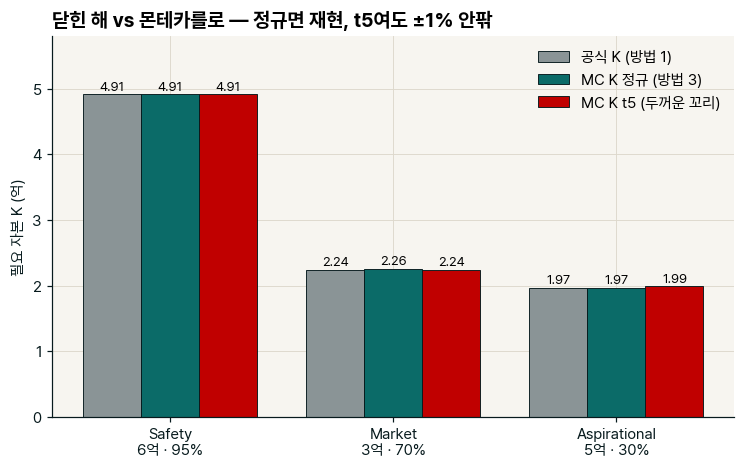

In [4]:
fig, ax = plt.subplots()
names = [g[0] for g in GOALS]; x = np.arange(3); bw = 0.26
for j, (lab, key, c) in enumerate([("공식 K (방법 1)", "closed", GRAY), ("MC K 정규 (방법 3)", "normal", TEAL), ("MC K t5 (두꺼운 꼬리)", "t5", RED)]):
    vals = [ROWS[n][key] if key == "closed" else ROWS[n][key][0] for n in names]
    bars = ax.bar(x + (j - 1) * bw, vals, bw, color=c, edgecolor=INK, lw=0.6, label=lab)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + bw / 2, v + 0.06, f"{v:.2f}", ha="center", fontsize=8.5)
ax.set_xticks(x, [f"{n}\n{G:.0f}억 · {p:.0%}" for n, G, p, *_ in GOALS]); ax.set_ylabel("필요 자본 K (억)"); ax.set_ylim(0, 5.8)
ax.set_title("닫힌 해 vs 몬테카를로 — 정규면 재현, t5여도 ±1% 안팎"); ax.legend(loc="upper right")
plt.show()

## 2. CPPI의 갭 위험 — 꼬리의 비용은 여기서 드러난다 (강의 50장 · 62장 각주)
자산 10억, floor = Safety 6억의 현재가치, m = 3, 매년 재조정. 해마다 연말 자산이 그 시점 floor 아래로 떨어진 적이 있으면 '위반'.

In [5]:
CP = {}
F_path = np.array([6.0 * math.exp(-r * (T - t - 1)) for t in range(T)])      # 해마다 연말의 floor
for kind, R in RK.items():
    W = run_cppi(10.0, 6.0, 3.0, R)
    breach = (W[:, 1:] < F_path - 1e-12).any(axis=1)
    A = W[:, -1]
    CP[kind] = dict(W=W, p6=np.mean(A >= 6), p9=np.mean(A >= 9), p14=np.mean(A >= 14), breach=breach.mean(), med=np.median(A),
                    worst=((W[:, 1:] - F_path) / F_path).min(axis=1))
    print(f"{kind:6s}: floor 위반 {CP[kind]['breach']:.1%} · ≥6억 {CP[kind]['p6']:.1%} · ≥9억 {CP[kind]['p9']:.1%} · ≥14억 {CP[kind]['p14']:.1%} · 중위 {CP[kind]['med']:.1f}억")
check("CPPI floor 위반 정규 (%)", 100 * CP["normal"]["breach"], 1.9, 0.05, ".2f"); check("CPPI floor 위반 t5 (%)", 100 * CP["t5"]["breach"], 3.3, 0.05, ".2f")
check("CPPI ≥6억 정규 (%)", 100 * CP["normal"]["p6"], 98.1, 0.05, ".1f"); check("CPPI ≥6억 t5 (%)", 100 * CP["t5"]["p6"], 96.7, 0.05, ".1f")
check("CPPI ≥9억 정규 (%)", 100 * CP["normal"]["p9"], 83.2, 0.05, ".1f"); check("CPPI ≥14억 정규 (%)", 100 * CP["normal"]["p14"], 64.5, 0.05, ".1f")
check("CPPI 중위 자산 (억)", CP["normal"]["med"], 18.0, 0.05, ".2f")
print(f"t5 / 정규 위반 비율 = {CP['t5']['breach'] / CP['normal']['breach']:.2f}배  — '두꺼운 꼬리는 갭 위험을 두 배로'")

normal: floor 위반 1.9% · ≥6억 98.1% · ≥9억 83.2% · ≥14억 64.5% · 중위 18.0억
t5    : floor 위반 3.3% · ≥6억 96.7% · ≥9억 84.3% · ≥14억 65.6% · 중위 18.1억
✓ CPPI floor 위반 정규 (%): 계산 1.87 · 강의 1.90 (허용 ±0.05)
✓ CPPI floor 위반 t5 (%): 계산 3.33 · 강의 3.30 (허용 ±0.05)
✓ CPPI ≥6억 정규 (%): 계산 98.1 · 강의 98.1 (허용 ±0.05)
✓ CPPI ≥6억 t5 (%): 계산 96.7 · 강의 96.7 (허용 ±0.05)
✓ CPPI ≥9억 정규 (%): 계산 83.2 · 강의 83.2 (허용 ±0.05)
✓ CPPI ≥14억 정규 (%): 계산 64.5 · 강의 64.5 (허용 ±0.05)
✓ CPPI 중위 자산 (억): 계산 17.96 · 강의 18.00 (허용 ±0.05)
t5 / 정규 위반 비율 = 1.78배  — '두꺼운 꼬리는 갭 위험을 두 배로'


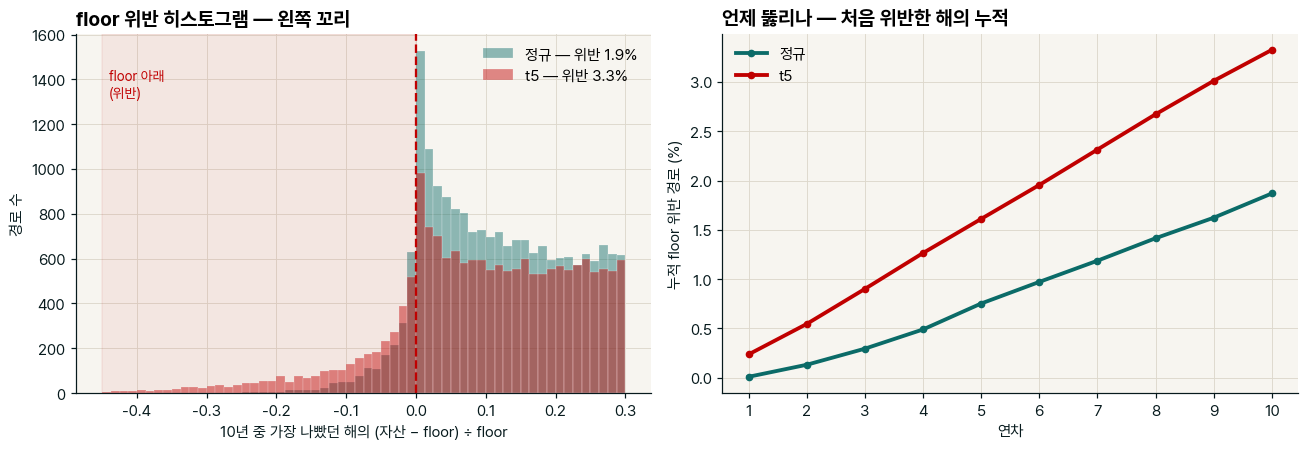

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
bins = np.linspace(-0.45, 0.3, 61)
for kind, c, lab in [("normal", TEAL, "정규"), ("t5", RED, "t5")]:
    ax1.hist(CP[kind]["worst"], bins=bins, color=c, alpha=0.45, label=f"{lab} — 위반 {CP[kind]['breach']:.1%}", edgecolor="white", lw=0.3)
ax1.axvspan(-0.45, 0, color=RED, alpha=0.06); ax1.axvline(0, color=RED, lw=1.5, ls="--")
ax1.text(-0.44, ax1.get_ylim()[1] * 0.9, "floor 아래\n(위반)", color=RED, fontsize=9, va="top")
ax1.set_xlabel("10년 중 가장 나빴던 해의 (자산 − floor) ÷ floor"); ax1.set_ylabel("경로 수")
ax1.set_title("floor 위반 히스토그램 — 왼쪽 꼬리"); ax1.legend(loc="upper right")
yr = np.arange(1, T + 1)
for kind, c, lab in [("normal", TEAL, "정규"), ("t5", RED, "t5")]:
    below = CP[kind]["W"][:, 1:] < F_path - 1e-12                 # 경로 × 연차: 그 해 연말에 floor 아래인가
    first_year = below.argmax(axis=1)[below.any(axis=1)]           # 처음 뚫린 해(위반 경로만)
    ax2.plot(yr, np.cumsum(np.bincount(first_year, minlength=T)) / N * 100, color=c, lw=2.5, marker="o", ms=4, label=lab)
ax2.set_xlabel("연차"); ax2.set_ylabel("누적 floor 위반 경로 (%)"); ax2.set_xticks(yr)
ax2.set_title("언제 뚫리나 — 처음 위반한 해의 누적"); ax2.legend()
fig.tight_layout(); plt.show()

## 3. 방법 2 문제를 몬테카를로로 (강의 56장)
① 1년 수익률 표본 200,000개를 한 번만(원문 자산 셋, seed 2026) ② 후보 비중을 정한다 — 격자 또는 효율선 위 γ 한 축
③ 후보마다 기대수익(μ로 바로)과 **미달 비율(표본 중 R < H인 비율 — 정규식이 아니라 센다)** ④ 미달 비율 ≤ α인 후보 중 기대수익 최대.
격자는 −100~200%를 2%p 간격으로 훑은 뒤 근처를 0.25%p로 다시, 롱온리는 0~100%, γ는 0.3~30 사이 400개.

In [7]:
NS = 50_000 if FAST else 200_000
MU = np.array([0.05, 0.10, 0.25])
S = np.array([[0.0025, 0, 0], [0, 0.04, 0.02], [0, 0.02, 0.25]])
ACCTS = [("은퇴", -0.10, 0.05), ("교육", -0.05, 0.15), ("상속", -0.15, 0.20)]
CLOSED = {"은퇴": [53.9, 26.6, 19.5], "교육": [37.9, 35.0, 27.1], "상속": [-78.9, 96.2, 82.7]}

def samples(rng, kind):
    L = np.linalg.cholesky(S)
    z = rng.standard_normal((NS, 3))
    if kind == "t5":                                   # 다변량 t(자유도 5): 분산을 맞추려고 √(3/5)를 곱한다
        w = rng.chisquare(5, NS) / 5
        z = z / np.sqrt(w)[:, None] * math.sqrt(3 / 5)
    return MU + z @ L.T

def evaluate(X, W, H, chunk=100):
    """후보 W(k × 3)마다 기대수익(μ로)과 미달 비율(표본에서 센다)"""
    m = W @ MU; miss = np.empty(len(W))
    for i in range(0, len(W), chunk):
        miss[i:i + chunk] = ((X @ W[i:i + chunk].T) < H).mean(axis=0)
    return m, miss

def best(W, m, miss, a):
    ok = miss <= a
    i = np.argmax(np.where(ok, m, -np.inf))
    return W[i], float(m[i]), float(miss[i])

def grid(lo, hi, step):
    v = np.round(np.arange(lo, hi + 1e-9, step), 6)
    a, b = np.meshgrid(v, v, indexing="ij")
    W = np.stack([a.ravel(), b.ravel(), 1 - a.ravel() - b.ravel()], 1)
    return W[(W[:, 2] >= lo - 1e-9) & (W[:, 2] <= hi + 1e-9)]

def solve_grid(X, H, a, lo, hi):
    W = grid(lo, hi, 0.02); n1 = len(W)
    m, miss = evaluate(X, W, H); w0 = best(W, m, miss, a)[0]
    v = np.arange(-0.04, 0.0401, 0.0025)
    a2, b2 = np.meshgrid(w0[0] + v, w0[1] + v, indexing="ij")
    W2 = np.stack([a2.ravel(), b2.ravel(), 1 - a2.ravel() - b2.ravel()], 1)
    W2 = W2[(W2.min(1) >= lo - 1e-9) & (W2.max(1) <= hi + 1e-9)]
    m2, miss2 = evaluate(X, W2, H); w, mm, ms = best(W2, m2, miss2, a)
    return {"w": np.round(w * 100, 1).tolist(), "mean": mm, "miss": ms, "candidates": n1 + len(W2)}

Si = np.linalg.inv(S); one = np.ones(3); A_ = one @ Si @ MU; C_ = one @ Si @ one
g_ = Si @ one / C_; v_ = Si @ (MU - A_ / C_ * one)
def solve_gamma(X, H, a):
    gam = np.geomspace(0.3, 30, 400)
    W = g_[None, :] + v_[None, :] / gam[:, None]
    m, miss = evaluate(X, W, H); w, mm, ms = best(W, m, miss, a)
    i = int(np.argmin(np.abs(W - w).sum(1)))
    return {"w": np.round(w * 100, 1).tolist(), "gamma": float(gam[i]), "mean": mm, "miss": ms, "candidates": len(W)}

t0 = time.time()
X = {k: samples(np.random.default_rng(SEED), k) for k in ("normal", "t5")}
DM = {}
for name, H, a in ACCTS:
    DM[name] = {"gamma": solve_gamma(X["normal"], H, a), "grid": solve_grid(X["normal"], H, a, -1.0, 2.0),
                "long": solve_grid(X["normal"], H, a, 0.0, 1.0), "gamma_t5": solve_gamma(X["t5"], H, a)}
print(f"표본 {NS:,} × 정규 · t5 · {time.time() - t0:.1f}초")
print(f"{'계좌':4s} {'닫힌 해':>20s} {'MC 격자 (후보 수)':>32s} {'MC γ 한 축':>30s} {'MC 롱온리':>20s}")
for name, *_ in ACCTS:
    d = DM[name]
    print(f"{name:4s} {str(CLOSED[name]):>20s} {str(d['grid']['w']):>22s} ({d['grid']['candidates']:,}) "
          f"{str(d['gamma']['w']):>22s} γ {d['gamma']['gamma']:.2f} {str(d['long']['w']):>20s}")

표본 200,000 × 정규 · t5 · 12.9초
계좌                   닫힌 해                     MC 격자 (후보 수)                       MC γ 한 축               MC 롱온리
은퇴     [53.9, 26.6, 19.5]     [52.5, 28.5, 19.0] (17,565)     [54.0, 26.5, 19.5] γ 3.80   [52.5, 28.5, 19.0]
교육     [37.9, 35.0, 27.1]     [38.5, 34.0, 27.5] (17,565)     [38.1, 34.8, 27.0] γ 2.72   [38.5, 34.0, 27.5]
상속    [-78.9, 96.2, 82.7]    [-76.5, 91.3, 85.2] (17,565)    [-80.9, 97.2, 83.6] γ 0.87     [0.0, 8.5, 91.5]


In [8]:
LECT_DM = {"은퇴": ([52.5, 28.5, 19.0], [54.0, 26.5, 19.5], 3.80, [52.5, 28.5, 19.0]),
           "교육": ([38.5, 34.0, 27.5], [38.1, 34.8, 27.0], 2.72, [38.5, 34.0, 27.5]),
           "상속": ([-76.5, 91.3, 85.2], [-80.9, 97.2, 83.6], 0.87, [0.0, 8.5, 91.5])}
for name, (lg, lgam, lgv, llo) in LECT_DM.items():
    d = DM[name]
    for i in range(3):
        check(f"{name} 격자 비중 {i + 1} (%)", d["grid"]["w"][i], lg[i], 0.05, ".1f")
        check(f"{name} γ 한 축 비중 {i + 1} (%)", d["gamma"]["w"][i], lgam[i], 0.05, ".1f")
        check(f"{name} 롱온리 비중 {i + 1} (%)", d["long"]["w"][i], llo[i], 0.05, ".1f")
    check(f"{name} γ", d["gamma"]["gamma"], lgv, 0.005, ".2f")
check("격자 후보 수(공매도 허용)", DM["은퇴"]["grid"]["candidates"], 17565, 0.5, ".0f")
check("γ 한 축 후보 수", DM["은퇴"]["gamma"]["candidates"], 400, 0.5, ".0f")
se_miss = math.sqrt(0.05 * 0.95 / NS)
print(f"α 5%에서 미달 비율의 표본오차 = ±{100 * se_miss:.2f}%p — 목적(기대수익)이 제약 근처에서 평평해 격자 해가 2~3%p 움직인다")
check("미달 비율 표본오차 α 5% (%p)", 100 * se_miss, 0.05, 0.005, ".3f")

✓ 은퇴 격자 비중 1 (%): 계산 52.5 · 강의 52.5 (허용 ±0.05)
✓ 은퇴 γ 한 축 비중 1 (%): 계산 54.0 · 강의 54.0 (허용 ±0.05)
✓ 은퇴 롱온리 비중 1 (%): 계산 52.5 · 강의 52.5 (허용 ±0.05)
✓ 은퇴 격자 비중 2 (%): 계산 28.5 · 강의 28.5 (허용 ±0.05)
✓ 은퇴 γ 한 축 비중 2 (%): 계산 26.5 · 강의 26.5 (허용 ±0.05)
✓ 은퇴 롱온리 비중 2 (%): 계산 28.5 · 강의 28.5 (허용 ±0.05)
✓ 은퇴 격자 비중 3 (%): 계산 19.0 · 강의 19.0 (허용 ±0.05)
✓ 은퇴 γ 한 축 비중 3 (%): 계산 19.5 · 강의 19.5 (허용 ±0.05)
✓ 은퇴 롱온리 비중 3 (%): 계산 19.0 · 강의 19.0 (허용 ±0.05)
✓ 은퇴 γ: 계산 3.80 · 강의 3.80 (허용 ±0.005)
✓ 교육 격자 비중 1 (%): 계산 38.5 · 강의 38.5 (허용 ±0.05)
✓ 교육 γ 한 축 비중 1 (%): 계산 38.1 · 강의 38.1 (허용 ±0.05)
✓ 교육 롱온리 비중 1 (%): 계산 38.5 · 강의 38.5 (허용 ±0.05)
✓ 교육 격자 비중 2 (%): 계산 34.0 · 강의 34.0 (허용 ±0.05)
✓ 교육 γ 한 축 비중 2 (%): 계산 34.8 · 강의 34.8 (허용 ±0.05)
✓ 교육 롱온리 비중 2 (%): 계산 34.0 · 강의 34.0 (허용 ±0.05)
✓ 교육 격자 비중 3 (%): 계산 27.5 · 강의 27.5 (허용 ±0.05)
✓ 교육 γ 한 축 비중 3 (%): 계산 27.0 · 강의 27.0 (허용 ±0.05)
✓ 교육 롱온리 비중 3 (%): 계산 27.5 · 강의 27.5 (허용 ±0.05)
✓ 교육 γ: 계산 2.72 · 강의 2.72 (허용 ±0.005)
✓ 상속 격자 비중 1 (%): 계산 -76.5 · 강의 -76.5 (허용 ±0.05)
✓ 상속 

**읽는 법** (56장) — 효율선 위 γ 한 축(변수 묶기)으로 찾으면 후보 400개로 닫힌 해와 0.1~2%p 안.
롱온리 상속은 0.0 · 8.5 · 91.5(닫힌 식 풀이 0 · 8.9 · 91.1). 같은 문제를 식 대신 세기로 — 가정이 바뀌어도 그대로 쓸 수 있습니다.

## 4. 두꺼운 꼬리로 바꾸면 — 닫힌 해가 못 하는 일 (강의 57장)
같은 평균 · 공분산의 **다변량 t(자유도 5)** 로 표본만 바꾸고 같은 (H, α)를 지키는 비중을 다시 셉니다(γ 한 축).
꼬리 점검으로 (H −20%, α 1%)도 함께.

In [9]:
tail = {k: solve_gamma(X[k], -0.20, 0.01) for k in ("normal", "t5")}
LECT_T5 = {"은퇴": [50.1, 28.6, 21.3], "교육": [18.6, 45.1, 36.3], "상속": [-161.9, 139.7, 122.2]}
print(f"{'계좌':14s} {'정규':>22s} {'t5':>24s}  읽는 법")
for name, *_ in ACCTS:
    wn, wt = DM[name]["gamma"]["w"], DM[name]["gamma_t5"]["w"]
    print(f"{name:14s} {str(wn):>22s} {str(wt):>24s}  채권 {'준다 — 덜 보수적' if wt[0] < wn[0] else '는다 — 더 보수적'}")
    for i in range(3):
        check(f"{name} t5 비중 {i + 1} (%)", wt[i], LECT_T5[name][i], 0.05, ".1f")
wn, wt = tail["normal"]["w"], tail["t5"]["w"]
print(f"{'꼬리 점검(−20%, 1%)':14s} {str(wn):>22s} {str(wt):>24s}  채권 {'는다 — 더 보수적' if wt[0] > wn[0] else '준다'}")
for i, (ln, lt) in enumerate(zip([50.6, 28.3, 21.1], [57.5, 24.7, 17.8])):
    check(f"꼬리 점검 정규 비중 {i + 1} (%)", wn[i], ln, 0.05, ".1f"); check(f"꼬리 점검 t5 비중 {i + 1} (%)", wt[i], lt, 0.05, ".1f")

계좌                                 정규                       t5  읽는 법
은퇴                 [54.0, 26.5, 19.5]       [50.1, 28.6, 21.3]  채권 준다 — 덜 보수적
✓ 은퇴 t5 비중 1 (%): 계산 50.1 · 강의 50.1 (허용 ±0.05)
✓ 은퇴 t5 비중 2 (%): 계산 28.6 · 강의 28.6 (허용 ±0.05)
✓ 은퇴 t5 비중 3 (%): 계산 21.3 · 강의 21.3 (허용 ±0.05)
교육                 [38.1, 34.8, 27.0]       [18.6, 45.1, 36.3]  채권 준다 — 덜 보수적
✓ 교육 t5 비중 1 (%): 계산 18.6 · 강의 18.6 (허용 ±0.05)
✓ 교육 t5 비중 2 (%): 계산 45.1 · 강의 45.1 (허용 ±0.05)
✓ 교육 t5 비중 3 (%): 계산 36.3 · 강의 36.3 (허용 ±0.05)
상속                [-80.9, 97.2, 83.6]   [-161.9, 139.7, 122.2]  채권 준다 — 덜 보수적
✓ 상속 t5 비중 1 (%): 계산 -161.9 · 강의 -161.9 (허용 ±0.05)
✓ 상속 t5 비중 2 (%): 계산 139.7 · 강의 139.7 (허용 ±0.05)
✓ 상속 t5 비중 3 (%): 계산 122.2 · 강의 122.2 (허용 ±0.05)
꼬리 점검(−20%, 1%)     [50.6, 28.3, 21.1]       [57.5, 24.7, 17.8]  채권 는다 — 더 보수적
✓ 꼬리 점검 정규 비중 1 (%): 계산 50.6 · 강의 50.6 (허용 ±0.05)
✓ 꼬리 점검 t5 비중 1 (%): 계산 57.5 · 강의 57.5 (허용 ±0.05)
✓ 꼬리 점검 정규 비중 2 (%): 계산 28.3 · 강의 28.3 (허용 ±0.05)
✓ 꼬리 점검 t5 비중 2 (%): 계산 24.7 · 강의 24.

**왜?** (57장) — 분산을 맞춘 t는 가운데가 뾰족하고 어깨(5~20%)가 얇습니다: 5% 분위수 −1.56σ(정규 −1.645σ), 1% 분위수는 −2.61σ(정규 −2.33σ).
그래서 α가 5~20%면 같은 (H, α)가 오히려 위험을 더 허용하고, α가 1%처럼 작으면 더 보수적으로 바뀝니다 — **어떤 α를 쓰는지가 결론을 바꿉니다.**

In [10]:
from scipy.stats import norm, t as tdist
for q in (0.05, 0.01):
    zn, zt = norm.ppf(q), tdist.ppf(q, 5) * math.sqrt(3 / 5)
    print(f"{q:.0%} 분위수: 정규 {zn:+.3f}σ · t5(분산 1) {zt:+.3f}σ")
check("t5 5% 분위수 (σ)", tdist.ppf(0.05, 5) * math.sqrt(3 / 5), -1.56, 0.005, ".2f")
check("정규 5% 분위수 (σ)", norm.ppf(0.05), -1.645, 0.0005, ".3f")
check("t5 1% 분위수 (σ)", tdist.ppf(0.01, 5) * math.sqrt(3 / 5), -2.61, 0.005, ".2f")
check("정규 1% 분위수 (σ)", norm.ppf(0.01), -2.33, 0.005, ".2f")
cross = __import__("scipy.optimize", fromlist=["brentq"]).brentq(lambda q: norm.ppf(q) - tdist.ppf(q, 5) * math.sqrt(3 / 5), 0.005, 0.04)
print(f"두 분위수가 같아지는 꼬리 확률 ≈ {cross:.1%} — 이보다 큰 α에선 t5가 덜, 작은 α에선 더 보수적")

5% 분위수: 정규 -1.645σ · t5(분산 1) -1.561σ
1% 분위수: 정규 -2.326σ · t5(분산 1) -2.606σ
✓ t5 5% 분위수 (σ): 계산 -1.56 · 강의 -1.56 (허용 ±0.005)
✓ 정규 5% 분위수 (σ): 계산 -1.645 · 강의 -1.645 (허용 ±0.0005)
✓ t5 1% 분위수 (σ): 계산 -2.61 · 강의 -2.61 (허용 ±0.005)
✓ 정규 1% 분위수 (σ): 계산 -2.33 · 강의 -2.33 (허용 ±0.005)
두 분위수가 같아지는 꼬리 확률 ≈ 2.9% — 이보다 큰 α에선 t5가 덜, 작은 α에선 더 보수적


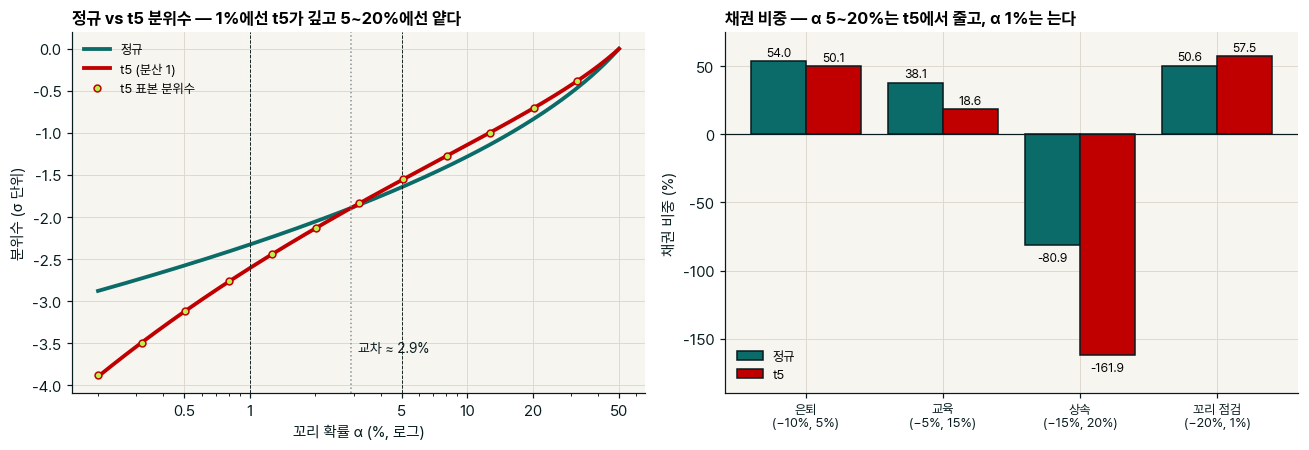

In [11]:
qs = np.geomspace(0.002, 0.5, 300)
zn = norm.ppf(qs); zt = tdist.ppf(qs, 5) * math.sqrt(3 / 5)
z_emp = np.sort(np.random.default_rng(SEED).standard_t(5, NS) * math.sqrt(3 / 5))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(qs * 100, zn, color=TEAL, lw=2.5, label="정규")
ax1.plot(qs * 100, zt, color=RED, lw=2.5, label="t5 (분산 1)")
ax1.scatter(qs[::25] * 100, np.quantile(z_emp, qs[::25]), s=20, color=LIME, edgecolor=RED, zorder=5, label="t5 표본 분위수")
ax1.axvline(cross * 100, color=GRAY, ls=":", lw=1)
ax1.text(cross * 100 * 1.08, -3.6, f"교차 ≈ {cross:.1%}", fontsize=9, color=INK)
for q in (1, 5):
    ax1.axvline(q, color=INK, lw=0.6, ls="--")
ax1.set_xscale("log"); ax1.set_xticks([0.5, 1, 5, 10, 20, 50], ["0.5", "1", "5", "10", "20", "50"])
ax1.set_xlabel("꼬리 확률 α (%, 로그)"); ax1.set_ylabel("분위수 (σ 단위)")
ax1.set_title("정규 vs t5 분위수 — 1%에선 t5가 깊고 5~20%에선 얕다", fontsize=11); ax1.legend(fontsize=8.5)
labs = ["은퇴\n(−10%, 5%)", "교육\n(−5%, 15%)", "상속\n(−15%, 20%)", "꼬리 점검\n(−20%, 1%)"]
bn = [DM[n]["gamma"]["w"][0] for n, *_ in ACCTS] + [tail["normal"]["w"][0]]
bt = [DM[n]["gamma_t5"]["w"][0] for n, *_ in ACCTS] + [tail["t5"]["w"][0]]
xx = np.arange(4)
ax2.bar(xx - 0.2, bn, 0.4, color=TEAL, edgecolor=INK, label="정규")
ax2.bar(xx + 0.2, bt, 0.4, color=RED, edgecolor=INK, label="t5")
for i in range(4):
    ax2.text(xx[i] - 0.2, bn[i] + (4 if bn[i] >= 0 else -12), f"{bn[i]:.1f}", ha="center", fontsize=8)
    ax2.text(xx[i] + 0.2, bt[i] + (4 if bt[i] >= 0 else -12), f"{bt[i]:.1f}", ha="center", fontsize=8)
ax2.axhline(0, color=INK, lw=0.8); ax2.set_xticks(xx, labs, fontsize=8.5); ax2.set_ylabel("채권 비중 (%)"); ax2.set_ylim(-190, 75)
ax2.set_title("채권 비중 — α 5~20%는 t5에서 줄고, α 1%는 는다", fontsize=11); ax2.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

**그래프 — 닫힌 해 vs MC(방법 2).** 계좌별 세 비중을 닫힌 해와 MC(γ 한 축 · 격자)로 나란히 봅니다.

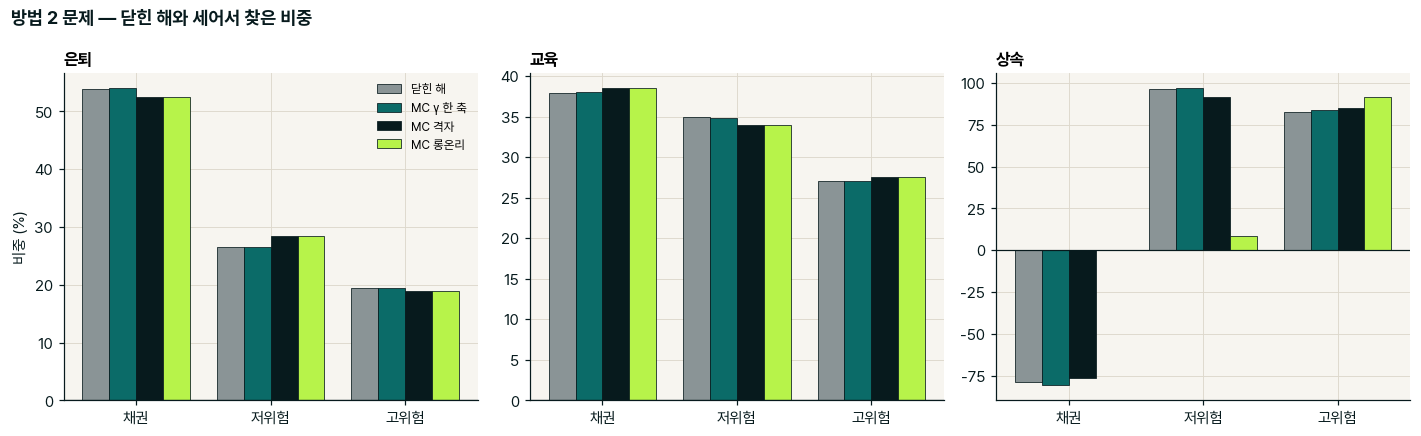

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
assets = ["채권", "저위험", "고위험"]
for ax, (name, *_ ) in zip(axes, ACCTS):
    vals = [CLOSED[name], DM[name]["gamma"]["w"], DM[name]["grid"]["w"], DM[name]["long"]["w"]]
    labs = ["닫힌 해", "MC γ 한 축", "MC 격자", "MC 롱온리"]
    cols = [GRAY, TEAL, INK, LIME]
    for j, (v, lab, c) in enumerate(zip(vals, labs, cols)):
        ax.bar(np.arange(3) + (j - 1.5) * 0.2, v, 0.2, color=c, edgecolor=INK, lw=0.5, label=lab)
    ax.axhline(0, color=INK, lw=0.8); ax.set_xticks(np.arange(3), assets); ax.set_title(name, fontsize=11)
axes[0].set_ylabel("비중 (%)"); axes[0].legend(fontsize=8)
fig.suptitle("방법 2 문제 — 닫힌 해와 세어서 찾은 비중", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(); plt.show()

## 5. 정리 (60장)
방법 1 · 2는 확률을 평균 · 변동성 조건으로 번역하고, 방법 3은 그 번역이 맞는지 경로로 확인합니다.
정규면 닫힌 해를 재현하고(검증), 분포만 바꾸면 두꺼운 꼬리 · 동적 규칙(CPPI)의 확률도 그대로 셀 수 있습니다.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 74 / 74 통과


---
## 바꿔 보기 (연습 문제)

1. CPPI 승수를 m = 3 → 5로 바꾸면(`run_cppi(10.0, 6.0, 5.0, R)`) 정규 · t5의 floor 위반 비율은? 1/m 규칙과 맞는가?
2. t 분포의 자유도를 5 → 3으로(꼬리가 더 두껍게) 바꾸면 Market · Aspirational의 MC K와 CPPI 위반은 어떻게 바뀌나? (분산을 맞추려면 √(1/3)을 곱한다)
3. 방법 2에서 표본 수를 20,000으로 줄이면(`NS`) 격자 해와 γ 한 축 해가 닫힌 해에서 얼마나 멀어지나? 시드를 바꿔 두세 번 보라.

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기